# 12 - Largest stable κ on the even strategy-5 grid

A sharp transition (large κ) squeezes 98% of the births into Δln a ≈ 9.2/κ around a_t. The strategy-5
grid at the time spread its nodes evenly in ln a_q over [a_min, 1], so fewer and fewer nodes land in
the birth window. This sweeps κ from 2 to 295 at a_t = 0.09 and asks, per grid setting, up to which κ
CLASS runs, stays finite and agrees with an 801-bin reference: Δχ² < 0.1 and max |ΔP_cb/P_cb| < 10⁻³.

**Result.**
- **Resolution.** 51 bins (the 10¹¹ GeV chains) are stable up to κ = 30; 201 bins to 75, 401 to 100.
  Beyond, the error grows past the signal: at κ = 100, Δχ² = 451 against a signal of 59. The birth
  window then holds 1–2 of the 51 nodes.
- **Overflow.** From κ = 294 every setting crashes. CLASS evaluates y = (a/a_t)^κ directly; at a_q = 1
  it overflows for κ > ln(DBL_MAX)/ln(1/a_t) ≈ 294.8, and the birth rate κ(x + y)/(1 + y)² becomes
  inf/inf. Writing the rate, Γ_acc and d ln f₀/d ln q in 1/y for y > 1 would remove this (`rate_safe`
  below); it is not done yet.
- **Large κ is a step.** Above κ ≈ 30 the converged spectra hardly change (Δχ² ≤ 1.5·10⁻³ against
  κ = 30 up to κ = 250 at f_acc = 0.01), so κ = 30 can stand in for any larger κ.
- **Smooth births** fail the P_cb tolerance at every κ; a few runs show a Δχ² ≈ 0.04 jump that does not
  depend on bins (κ = 3, 8), also seen in notebooks 16–18.

The born-fraction grid (default since 2026-10-05) fixes the resolution problem: notebook 18.

Settings: the 10¹¹ GeV chain `connect/Lite_lin/11` (m = 10¹¹ GeV, ΛCDM best fit), a_t = 0.09,
f_acc = 0.01, no sink, even grid. Δχ²: `accdm_nb.chi2_parts`. Runs are forked with a timeout, so a
crash is recorded, not fatal; cached in `12_cache.pkl` (about 1.5 h from scratch).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from accdm_nb import (KK, LITE_LIN_11, LCDM_LITE_LIN_11, RunCache, a_min, born_fraction, chi2_parts, ok,
                      q_size, status, plot_style)

plot_style()

A_T, F_ACC, F_NULL = 0.09, 1e-2, 1e-6
KAPPAS = [2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 250, 290, 295]
K_OVERFLOW = np.log(np.finfo(float).max)/np.log(1/A_T)
DCHI2_TOL, PK_TOL = 0.1, 1e-3
SETTINGS = {**LITE_LIN_11, 'a_t_acc': A_T, 'acc_de_sink': 'no', 'ncdm_quadrature_strategy': '0, 5'}


def bins(n):
    return {'ncdm_N_momentum_bins': '15, {:d}'.format(n)}


SETUPS = {'51': bins(51), '101': bins(101), '201': bins(201), '401': bins(401), '801': bins(801),
          '50/dec': {}, '200/dec': {'accdm_q_bins_per_decade': 200},
          '51, q_tol 1e-9': {**bins(51), 'accdm_q_number_tol': 1e-9},
          '51, tol_pert 1e-6': {**bins(51), 'tol_perturbations_integration': 1e-6},
          '51, smooth births': {**bins(51), 'accdm_smooth_births': 1}}
REF, REF_CHECK = '801', '401'           # 401 vs 801 estimates the reference's own error


def params(kappa, lab, f_acc=F_ACC):
    return {**LCDM_LITE_LIN_11, **SETTINGS, **SETUPS[lab], 'kappa_acc': float(kappa), 'f_acc': f_acc}


print('(a_q/a_t)^kappa overflows at a_q = 1 for kappa > {:.2f}'.format(K_OVERFLOW))

(a_q/a_t)^kappa overflows at a_q = 1 for kappa > 294.77


## 1. The grid without CLASS

Nodes inside the birth window (0.01 < F < 0.99) per setting, and nodes where the birth rate as CLASS
writes it is NaN.

In [2]:
def nodes_in_birth(kappa, extra):
    amin = a_min(kappa, A_T, extra.get('accdm_q_number_tol', 1e-6))
    n = int(extra['ncdm_N_momentum_bins'].split(',')[1]) if 'ncdm_N_momentum_bins' in extra else \
        q_size(extra.get('accdm_q_bins_per_decade', 50), amin)
    F = born_fraction(np.exp(np.linspace(np.log(amin), 0, n)), kappa, A_T)
    return n, int(np.sum((F > 0.01) & (F < 0.99)))


def nan_nodes(kappa, n=51):
    a = np.exp(np.linspace(np.log(a_min(kappa, A_T)), 0, n))
    with np.errstate(over='ignore', invalid='ignore'):
        x, y = a**kappa, (a/A_T)**kappa
        return int(np.sum(~np.isfinite(kappa*(x + y)/(1 + y)**2)))


def rate_safe(lna, kappa):
    """dF/dln a written in 1/y where y > 1: finite at any kappa."""
    lny = kappa*(lna - np.log(A_T))
    x, u = np.exp(kappa*lna), np.exp(-np.abs(lny))
    return np.where(lny > 0, kappa*(x*u + 1)*u/(1 + u)**2, kappa*(x + u)/(1 + u)**2)


GRID_LABS = ['51', '201', '801', '50/dec', '200/dec']
print('{:>6} {:>9} {:>4}'.format('kappa', 'a_min', 'NaN') + ''.join('{:>10}'.format(l) for l in GRID_LABS))
for k in KAPPAS:
    print('{:>6g} {:>9.2e} {:>4d}'.format(k, a_min(k, A_T), nan_nodes(k)) + ''.join(
        '{:>10}'.format('{}/{}'.format(*nodes_in_birth(k, SETUPS[l]))) for l in GRID_LABS))
print('(bins / nodes inside the births)')

 kappa     a_min  NaN        51       201       801    50/dec   200/dec
     2  8.96e-05    0     51/23    201/93   801/370    205/95   811/374
     3  9.00e-04    0     51/22    201/87   801/347    155/67   611/264
     5  5.68e-03    0     51/18    201/71   801/284    115/41   451/160
     8  1.60e-02    0     51/14    201/56   801/223     91/25   361/100
    12  2.85e-02    0     51/11    201/43   801/172     79/17    311/67
    20  4.51e-02    0      51/7    201/30   801/118     69/10    271/40
    30  5.68e-02    0      51/5    201/21    801/86      65/7    251/27
    50  6.83e-02    0      51/3    201/14    801/55      61/4    235/16
    75  7.49e-02    0      51/2     201/9    801/38      59/3    227/11
   100  7.84e-02    0      51/2     201/7    801/29      57/2     223/8
   150  8.21e-02    0      51/1     201/5    801/20      57/1     219/5
   200  8.40e-02    0      51/1     201/4    801/15      55/1     217/4
   250  8.52e-02    0      51/1     201/3    801/12      55/1   

## 2. CLASS runs

In [3]:
cache = RunCache('12_cache.pkl', timeout=900)
null = cache(params(5, '51', F_NULL))
res = dict(zip([(lab, k) for k in KAPPAS for lab in SETUPS],
               cache.many([params(k, lab) for k in KAPPAS for lab in SETUPS])))


def compare(lab, k, base=REF):
    a, b = res[(lab, k)], res[(base, k)]
    if not (ok(a) and ok(b)):
        return None
    return {'dchi2': chi2_parts(a, b)['total'], 'dpk': float(np.max(np.abs(a['pk_cb']/b['pk_cb'] - 1)))}


def verdict(lab, k):
    """. stable, X dchi2 > tol, P P_cb > tol, E error/crash, N non-finite, u reference unconverged."""
    out = res[(lab, k)]
    if 'error' in out:
        return 'E'
    if not ok(out):
        return 'N'
    if lab == REF:
        c = compare(REF_CHECK, k)
        return '.' if c and c['dchi2'] < DCHI2_TOL/10 and c['dpk'] < PK_TOL/10 else 'u'
    c = compare(lab, k)
    return '?' if c is None else 'X' if c['dchi2'] > DCHI2_TOL else 'P' if c['dpk'] > PK_TOL else '.'


print('{:>6}'.format('kappa') + ''.join('{:>8}'.format(l[:7]) for l in SETUPS))
for k in KAPPAS:
    print('{:>6g}'.format(k) + ''.join('{:>8}'.format(verdict(l, k)) for l in SETUPS))
print('\n. stable   X dchi2 > {:g}   P max|dP_cb/P_cb| > {:g}   E CLASS error   u reference unconverged'.format(
    DCHI2_TOL, PK_TOL))
print('crashes:', sorted({status(res[(l, k)]) for l in SETUPS for k in KAPPAS if 'error' in res[(l, k)]}))

 kappa      51     101     201     401     801  50/dec 200/dec 51, q_t 51, tol 51, smo
     2       .       .       .       .       .       .       .       .       .       P
     3       .       .       .       .       u       .       .       .       .       P
     5       .       .       .       .       u       .       .       .       .       P
     8       .       .       .       .       u       .       .       .       .       P
    12       .       .       .       .       .       .       .       .       .       P
    20       .       .       .       .       .       .       .       .       .       P
    30       .       .       .       .       .       P       .       X       .       P
    50       X       P       .       .       .       X       .       X       X       X
    75       X       X       .       .       .       X       .       X       X       X
   100       X       X       P       .       .       X       .       X       X       X
   150       X       X       X       P     

## 3. The 51-bin grid in numbers

Against the 801-bin reference; *signal* is the reference against f_acc = 10⁻⁶, *ref error* the 401 vs
801 difference.

 kappa      dchi2   max dPcb     signal    ref err
     2   4.33e-04   3.47e-05       55.9   2.28e-06
     3   4.15e-02   3.12e-05       57.7   4.13e-02
     5   4.37e-04   2.55e-05       58.6   4.14e-02
     8   4.17e-02   2.59e-05       58.9   4.14e-02
    12   4.24e-04   3.52e-05       58.9   1.43e-06
    20   1.47e-03   3.65e-04       58.9   1.33e-07
    30   7.04e-02   7.57e-04       58.9   4.86e-07
    50   2.00e+00   3.01e-02       58.9   3.76e-07
    75   8.52e+00   9.15e-02       58.8   2.76e-07
   100   4.51e+02   3.28e-01       58.8   1.09e-07
   150   7.56e+02   3.73e-01       58.8   9.27e-04
   200   3.08e+02   4.84e-01       58.7   3.03e-02
   250   3.71e+07   4.92e+01       58.7   4.84e-02
   290   4.21e+04   8.00e-01       58.5   3.37e+00
   295  CLASS process died, exit code -11


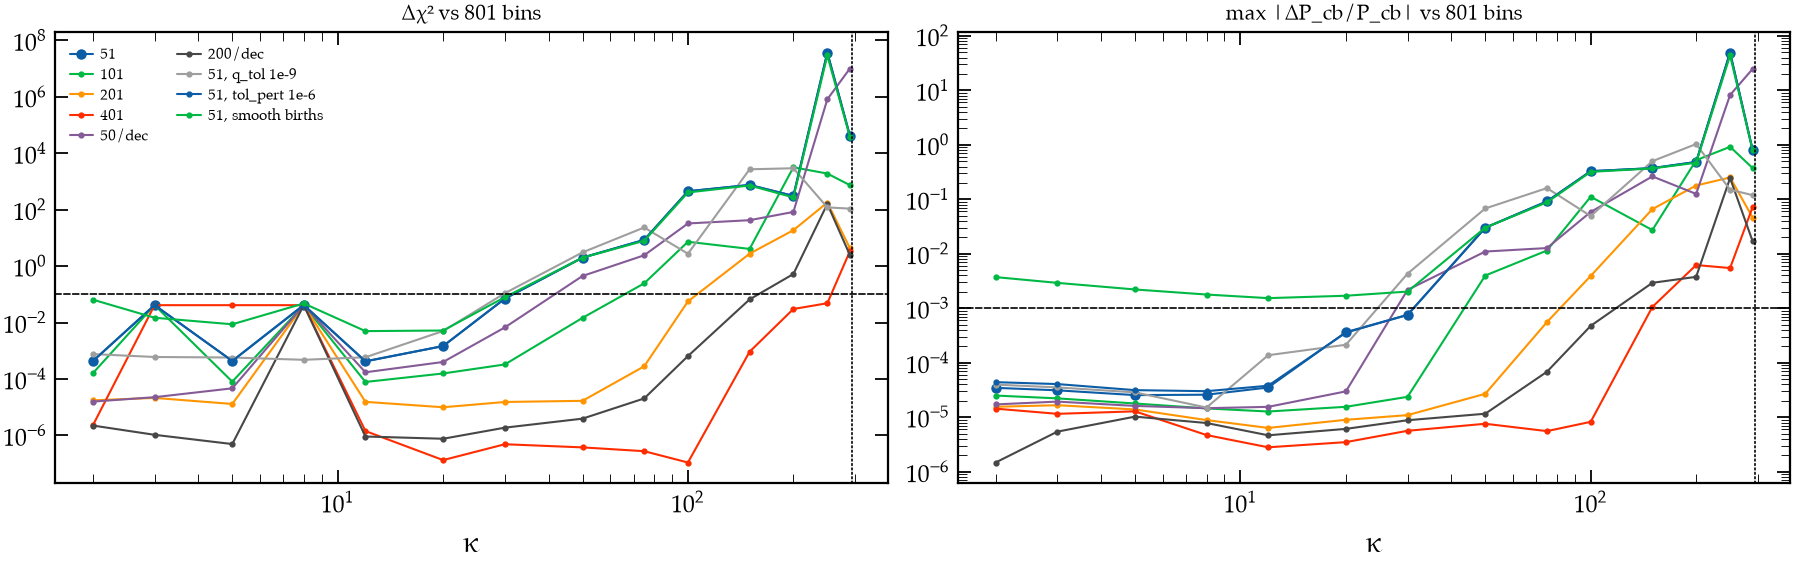

In [4]:
print('{:>6} {:>10} {:>10} {:>10} {:>10}'.format('kappa', 'dchi2', 'max dPcb', 'signal', 'ref err'))
for k in KAPPAS:
    c, r = compare('51', k), compare(REF_CHECK, k)
    if c is None:
        print('{:>6g}  {}'.format(k, status(res[('51', k)])))
        continue
    print('{:>6g} {:>10.2e} {:>10.2e} {:>10.3g} {:>10.2e}'.format(
        k, c['dchi2'], c['dpk'], chi2_parts(res[(REF, k)], null)['total'], r['dchi2'] if r else np.nan))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for lab in SETUPS:
    if lab == REF:
        continue
    pts = [(k, compare(lab, k)) for k in KAPPAS]
    pts = [(k, c) for k, c in pts if c]
    for ax, key in zip(axes, ('dchi2', 'dpk')):
        ax.loglog([k for k, _ in pts], [max(c[key], 1e-12) for _, c in pts], 'o-' if lab == '51' else '.-',
                  ms=4, lw=1, label=lab)
for ax, tol, name in zip(axes, (DCHI2_TOL, PK_TOL), ('Δχ² vs 801 bins', 'max |ΔP_cb/P_cb| vs 801 bins')):
    ax.axhline(tol, color='k', ls='--', lw=0.8)
    ax.axvline(K_OVERFLOW, color='k', ls=':', lw=0.8)
    ax.set_xlabel('κ')
    ax.set_title(name, fontsize=10)
axes[0].legend(fontsize=7, ncol=2)
plt.show()

## 4. Is large κ distinguishable from κ = 30?

The 801-bin run at each κ against the 801-bin run at κ = 30. Rows where the κ difference is below the
reference error say nothing and are flagged.

In [5]:
base = res[(REF, 30)]
print('{:>6} {:>10} {:>10} {:>12} {:>10}'.format('kappa', 'dchi2', 'max dPcb', 'dsigma8_cb', 'ref err'))
for k in KAPPAS:
    a = res[(REF, k)]
    if not ok(a):
        continue
    d, r = chi2_parts(a, base)['total'], compare(REF_CHECK, k)
    rerr = r['dchi2'] if r else np.nan
    print('{:>6g} {:>10.2e} {:>10.2e} {:>+12.2e} {:>10.2e}{}'.format(
        k, d, np.max(np.abs(a['pk_cb']/base['pk_cb'] - 1)), a['sigma8_cb']/base['sigma8_cb'] - 1, rerr,
        '  (below ref err)' if k != 30 and not rerr < d else ''))

 kappa      dchi2   max dPcb   dsigma8_cb    ref err
     2   7.25e-02   2.09e-03    +2.46e-04   2.28e-06
     3   2.70e-02   1.01e-03    +1.55e-04   4.13e-02  (below ref err)
     5   1.02e-02   3.55e-04    +5.04e-05   4.14e-02  (below ref err)
     8   4.54e-02   1.29e-04    +1.68e-05   4.14e-02
    12   1.23e-03   5.02e-05    +6.36e-06   1.43e-06
    20   1.27e-04   1.20e-05    +1.61e-06   1.33e-07
    30   0.00e+00   0.00e+00    +0.00e+00   4.86e-07
    50   1.11e-04   7.77e-06    -1.23e-06   3.76e-07
    75   3.12e-04   1.08e-05    -1.22e-06   2.76e-07
   100   5.05e-04   1.13e-05    -2.06e-06   1.09e-07
   150   8.50e-04   1.98e-05    -3.76e-06   9.27e-04  (below ref err)
   200   1.18e-03   4.20e-05    -1.32e-05   3.03e-02  (below ref err)
   250   1.48e-03   6.82e-05    +2.31e-05   4.84e-02  (below ref err)
   290   4.26e-03   1.69e-03    +8.39e-04   3.37e+00  (below ref err)
